In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel("numiqo.xlsx", sheet_name="Data")
print(data.shape)
data.head() 

(36, 4)


,Disease,Age,Gender,Smoker status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker


In [3]:
print(data.isnull().sum())  

Disease          0
Age              0
Gender           0
Smoker status    0
dtype: int64


In [4]:
data["Disease"] = data["Disease"].map({
    "diseased": 1,
    "not diseased": 0
})
data["Gender"] = data["Gender"].map({
    "Male": 1,
    "Female": 0
})
data["Smoker status"] = data["Smoker status"].map({
    "Smoker": 1,
    "Non-smoker": 0
})
data.head() 

,Disease,Age,Gender,Smoker status
0,1,43,1,1
1,0,18,1,1
2,1,22,0,0
3,1,25,1,0
4,0,45,0,1


In [5]:
feature_cols = ["Age", "Gender", "Smoker status"]
X = data[feature_cols]
y = data["Disease"]  

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)
print(X_train.shape)
print(X_test.shape) 

(28, 3)
(8, 3)


In [7]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)  

In [8]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix :")
print(conf_mat)
accuracy = metrics.accuracy_score(y_test, y_pred)
print("\nAccuracy Score :", accuracy)
print("Accuracy Percentage :", accuracy*100)
print("\nClassification Report\n")
print(metrics.classification_report(y_test, y_pred)) 

Confusion Matrix :
[[2 0]
 [1 5]]

Accuracy Score : 0.875
Accuracy Percentage : 87.5

Classification Report

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.83      0.91         6

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8



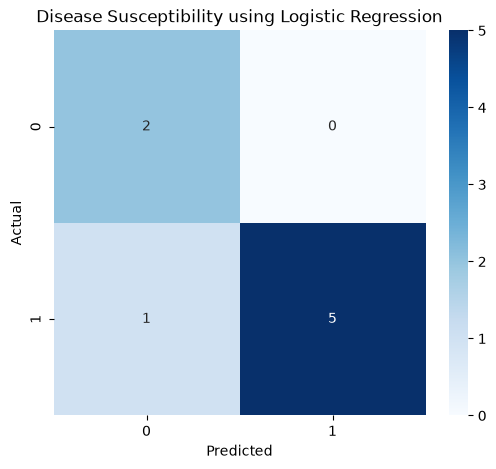

In [9]:
confusion = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Disease Susceptibility using Logistic Regression")
plt.show()  

In [10]:
sample = pd.DataFrame(
    [[55,1,1]],
    columns=feature_cols
)
prediction = model.predict(sample)
probability = model.predict_proba(sample)
print("Prediction :", prediction[0])
print("Probability :", probability)
if prediction[0]==1:
    print("Person is predicted to be Diseased")
else:
    print("Person is predicted to be Not Diseased")  

Prediction : 1
Probability : [[0.27529951 0.72470049]]
Person is predicted to be Diseased
